In [ ]:
# 1. Download the inference results if not already downloaded.

!wget "https://surfdrive.surf.nl/files/index.php/s/G8XWW8On5MWhtCk/download?path=%2FInference&files=inference_results_ToyExample-v2_Cologne-v1_CologneBonnDusseldorf-v1.csv" -qO inference_results.csv

# 2. Model checkpoints should be in ../outputs/Cologne-v1/vdn_rnn/

/Users/pbhustali/miniforge3/envs/impact-jaxmarl-env/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [1]:
import jax
import jaxmarl

from rollout_data_generator import RolloutDataGenerator
from plotter import RolloutPlotter, plot_action_stats

In [2]:
ENV_NAME = 'Cologne-v1'
ALG = 'vdn_rnn'
env = jaxmarl.make("road_env", map_name=ENV_NAME)
rdg = RolloutDataGenerator(ENV_NAME, ALG, test_num_envs=10)
rp = RolloutPlotter(env)

Selected best checkpoint dir and id
Checkpoint dir: 2025-04-29_15-09-09.495665, checkpoint id: 22320


In [3]:
key = jax.random.PRNGKey(87)
episode_data = rdg.generate_rollout_data(key, verbose=True)

action                              (10, 50, 60)
applied_actions                     (10, 50, 60)
budget_constraints_applied          (10, 50)
budget_remaining                    (10, 51)
edge_beliefs                        (10, 51, 60, 5)
edge_observations                   (10, 51, 60)
edge_states                         (10, 51, 60)
episode_cost                        (10, 1)
forced_replace_constraint_applied   (10, 50)
maintenance_reward                  (10, 50)
reward                              (10, 50)
terminal_reward                     (10, 50)
timesteps                           (10, 51)
total_travel_time                   (10, 50)
traffic_volumes                     (10, 50, 60)
travel_time_reward                  (10, 50)
travel_times                        (10, 50, 60)


In [4]:
# rdg.save_rollout_data(episode_data)

# episode_data = rdg.load_rollout_data()

In [5]:
# get data for a single episode among all the episode_data
single_episdode_data = rdg.get_single_episode_data(episode_data, episode_idx=0)

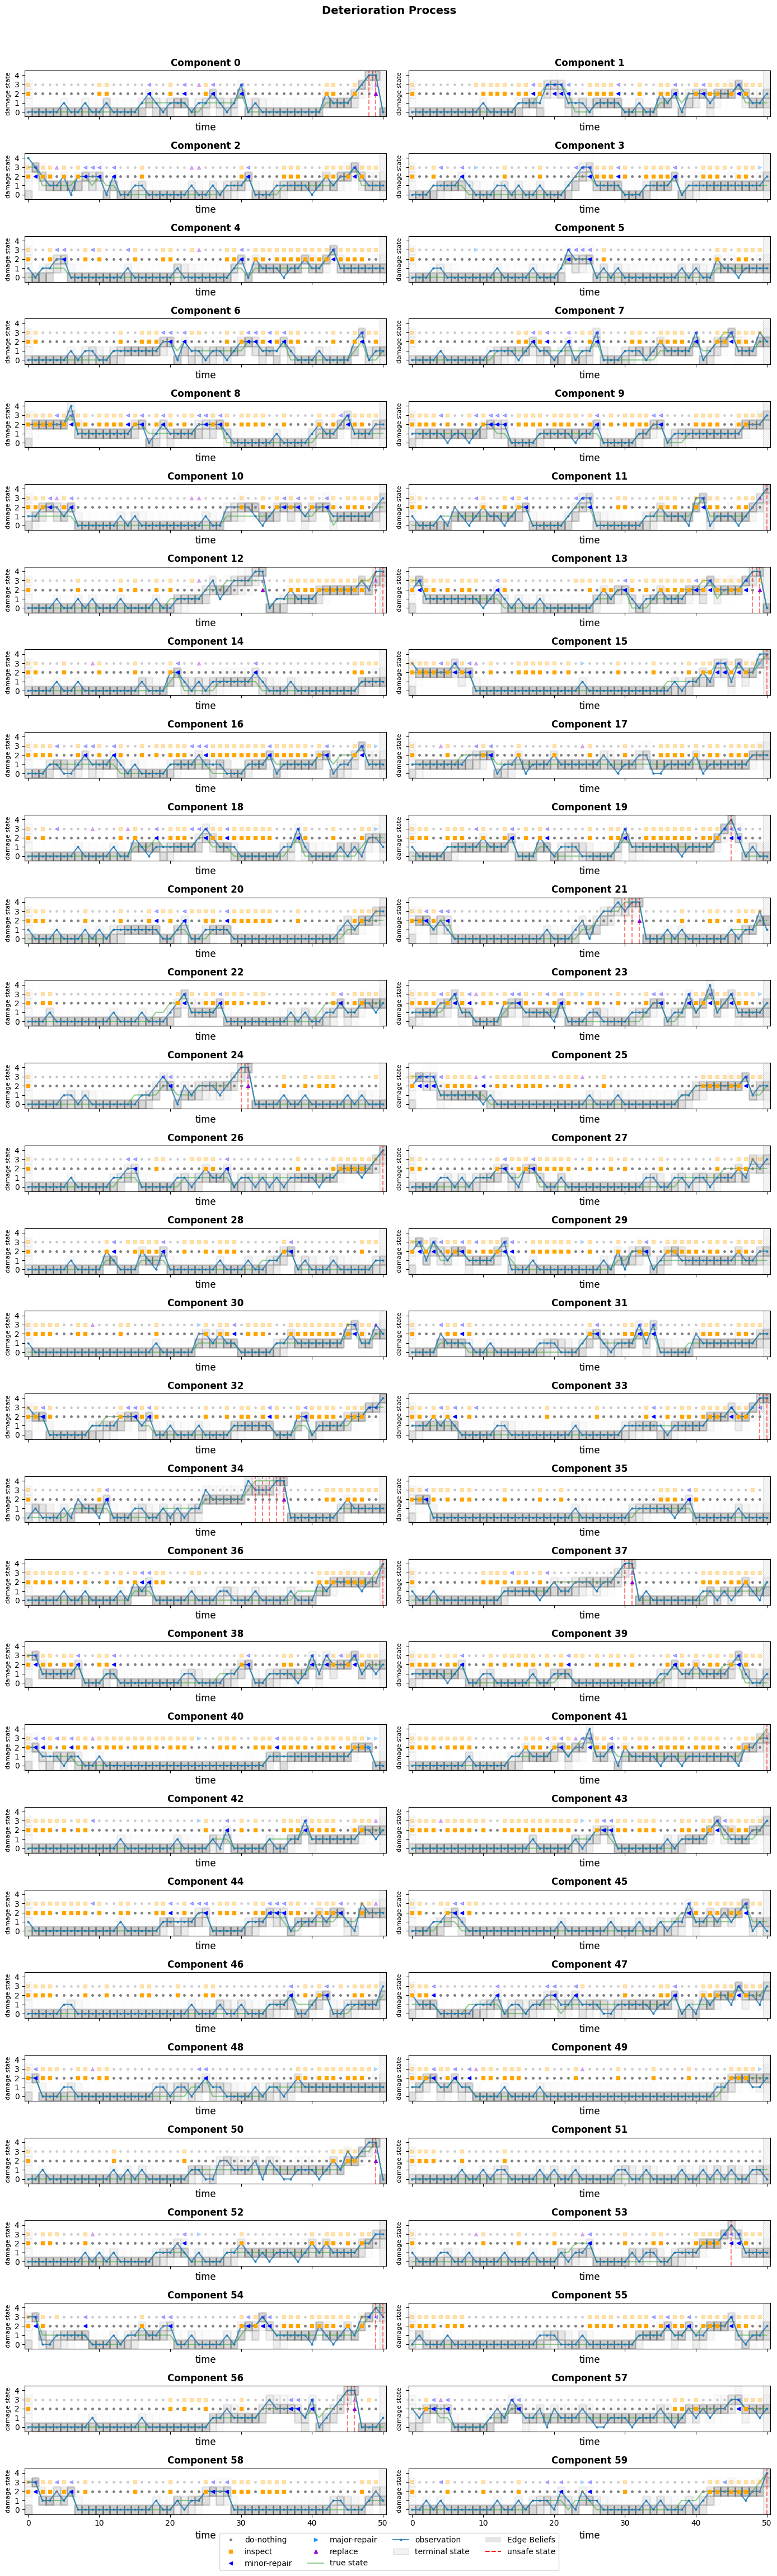

In [6]:
save_fig_kwargs = {
    "fname": f"./rollout_{ENV_NAME}_{ALG}.png",
    "dpi": 300,
    "bbox_inches": "tight",
}

rp._plot_deterioration(single_episdode_data, save_fig_kwargs)

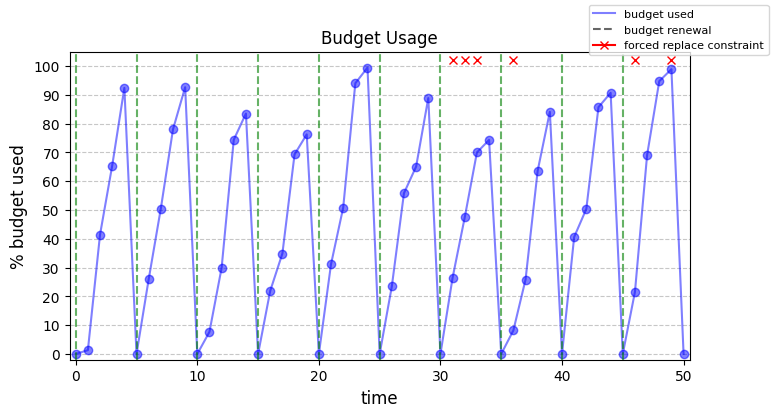

In [7]:
rp._plot_budget(single_episdode_data)

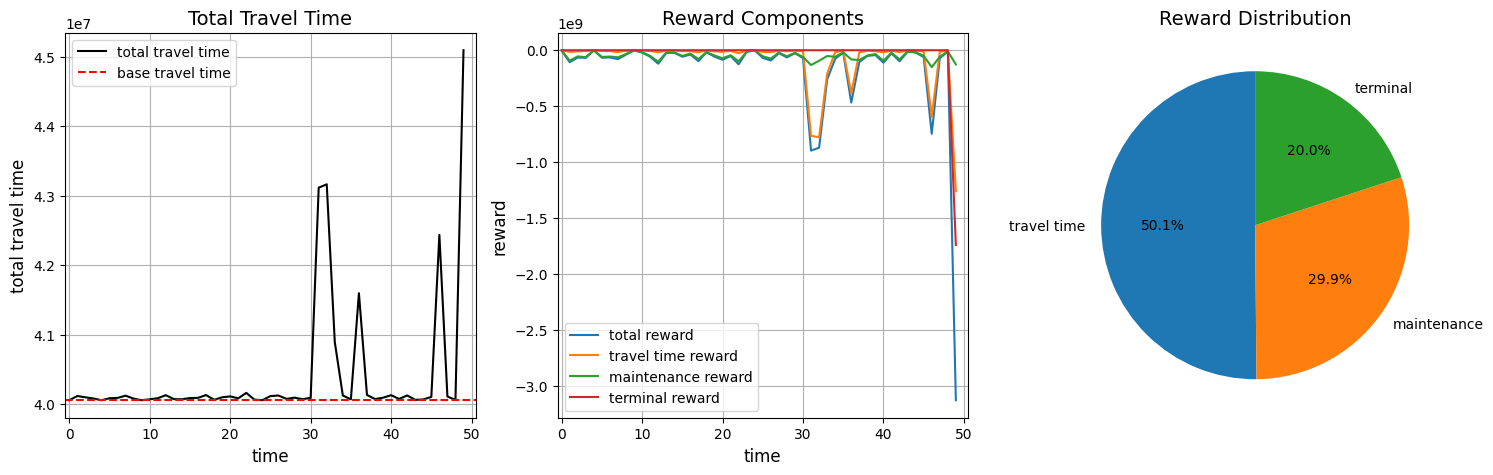

In [8]:
rp._plot_travel_time_and_rewards(single_episdode_data)

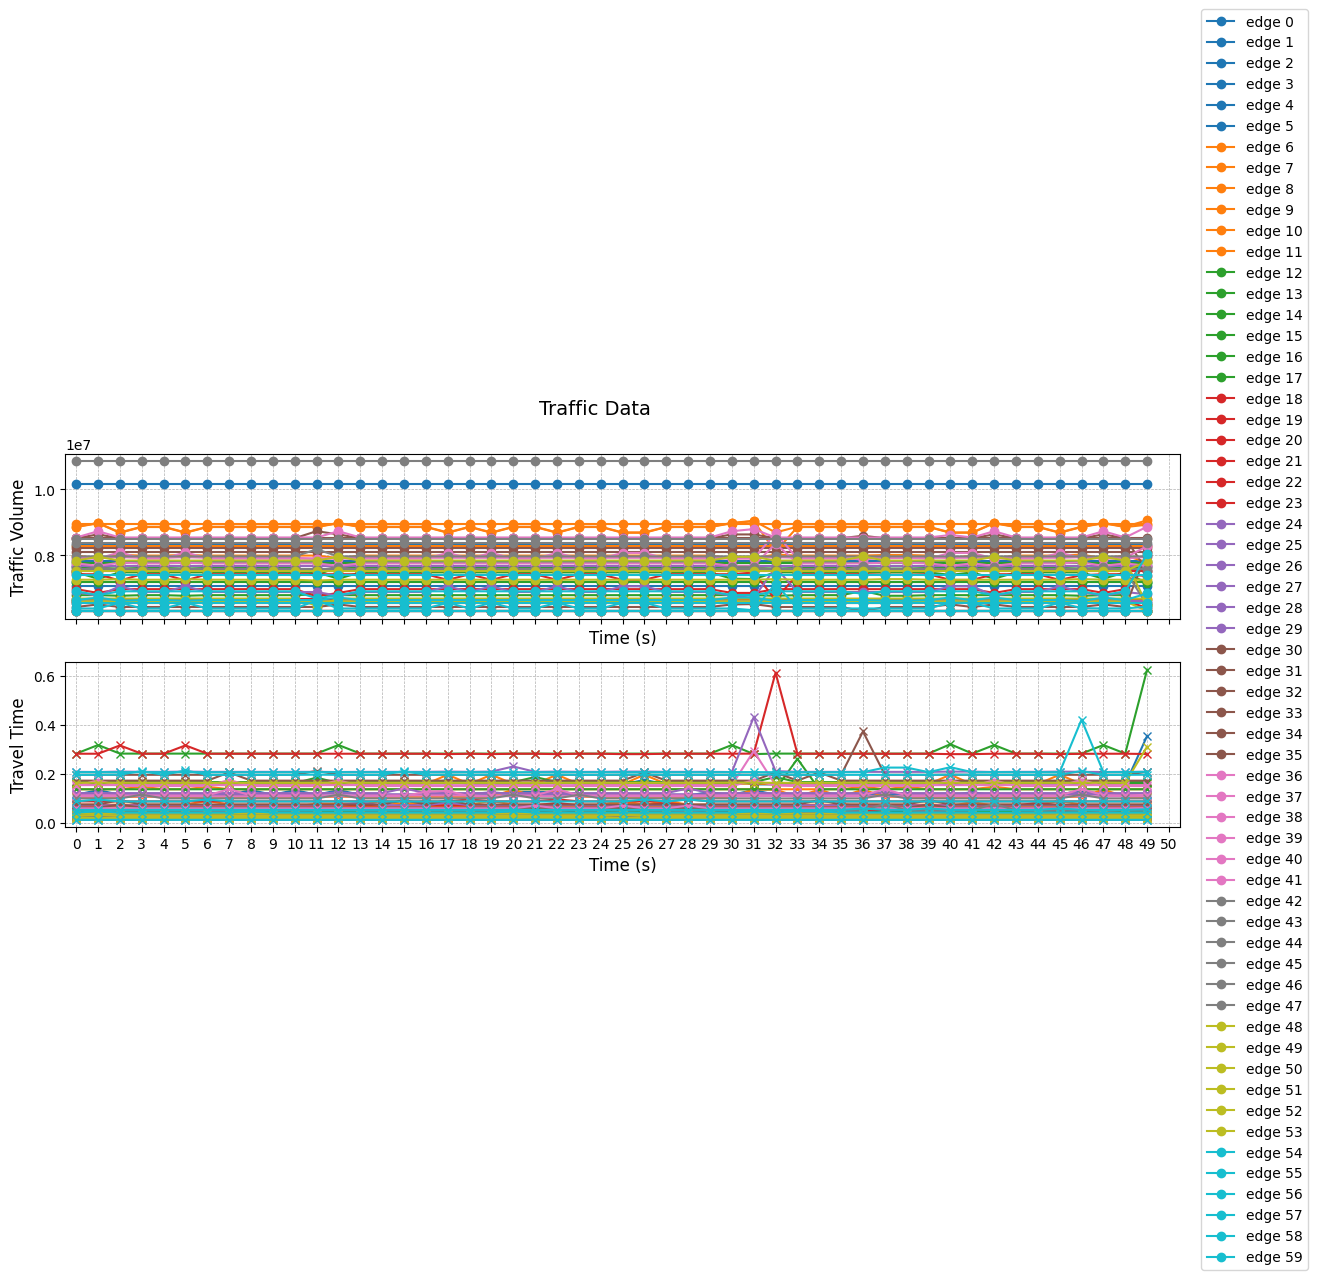

In [9]:
# ToDo: return travel times and traffic volumes in info from jax env
rp._plot_traffic_volume_and_travel_times(single_episdode_data)

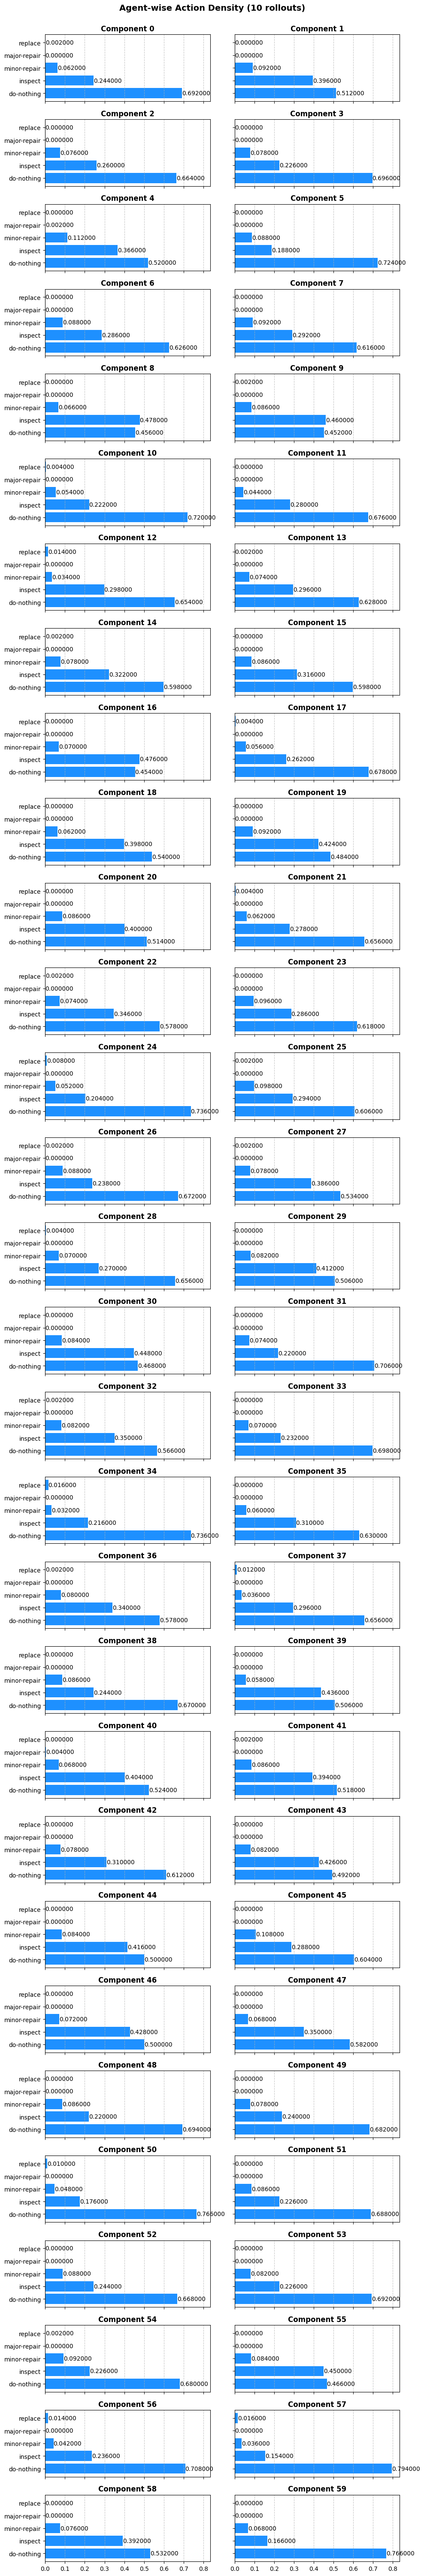

In [20]:
save_fig_kwargs = {
    "fname": f"./rollout_{ENV_NAME}_{ALG}_action_hist.png",
    "dpi": 300,
    "bbox_inches": "tight",
}

plot_action_stats(episode_data['applied_actions'][:1000], save_kwargs=save_fig_kwargs)